# 07. Temporal Robustness & Edited AI Analysis

**Цель:** Оценить cascade-детектор на новых данных:
1. **Temporal robustness** — FPR на свежих human-текстах (2024-2026)
2. **Degradation curve** — как confidence падает при разных уровнях редактирования AI-текстов

**Данные:**
- `data/human_fresh/` — 3000 свежих human-текстов (Habr, N+1, Wiki)
- `data/edited_ai/` — 750 edited AI-текстов (6 уровней: light_edit → full_rewrite)

**Модели:**
- Baseline C (TF-IDF, topic-matched) — переобучается из train_tm
- Transformer (ruRoBERTa-large) — загружается из artifacts/transformer/model/
- Cascade: TF-IDF → если confidence в [0.30, 0.70] → Transformer

In [ ]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, classification_report
from scipy.sparse import hstack

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")

SEED = 42
np.random.seed(SEED)

## 1. Загрузка данных

In [2]:
def load_jsonl(path):
    with open(path, encoding="utf-8") as f:
        return [json.loads(line) for line in f]

# Training data (для переобучения Baseline C)
train_tm = load_jsonl(PROJECT_ROOT / "data/splits/train_tm.jsonl")
val_tm = load_jsonl(PROJECT_ROOT / "data/splits/val_tm.jsonl")

# Fresh human
habr_fresh = load_jsonl(PROJECT_ROOT / "data/human_fresh/habr_fresh.jsonl")
nplus1_fresh = load_jsonl(PROJECT_ROOT / "data/human_fresh/nplus1_fresh.jsonl")
wiki_fresh = load_jsonl(PROJECT_ROOT / "data/human_fresh/wiki_fresh.jsonl")

all_fresh_human = habr_fresh + nplus1_fresh + wiki_fresh

print(f"Train TM: {len(train_tm)}")
print(f"Val TM: {len(val_tm)}")
print(f"Fresh human: Habr={len(habr_fresh)}, N+1={len(nplus1_fresh)}, Wiki={len(wiki_fresh)}, Total={len(all_fresh_human)}")

Train TM: 9000
Val TM: 1200
Fresh human: Habr=1000, N+1=1000, Wiki=1000, Total=3000


In [3]:
# Edited AI
edited_dir = PROJECT_ROOT / "data/edited_ai"
edited_data = {}
for f in sorted(edited_dir.glob("edited_*.jsonl")):
    level = f.stem.replace("edited_", "").rsplit("_", 2)[0]  # extract level name
    # Более надёжный парсинг: берём из meta
    rows = load_jsonl(f)
    if rows:
        level = rows[0].get("meta", {}).get("edit_level", level)
    edited_data[level] = rows
    print(f"{level:15s}: {len(rows)} texts")

print(f"\nTotal edited: {sum(len(v) for v in edited_data.values())}")

heavy_edit     : 150 texts
light_edit     : 150 texts
mixed          : 150 texts
replace_10     : 100 texts
replace_30     : 100 texts
replace_50     : 100 texts

Total edited: 750


## 2. Обучение Baseline C (TF-IDF topic-matched)

In [4]:
# Объединяем train + val для финальной модели
all_train = train_tm + val_tm
train_texts = [r["text"] for r in all_train]
train_labels = [r["label"] if isinstance(r["label"], int) else (1 if r["label"] == "ai" else 0) for r in all_train]

# TF-IDF: char 3-5 + word 1-2
tfidf_char = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), max_features=50000, sublinear_tf=True)
tfidf_word = TfidfVectorizer(analyzer="word", ngram_range=(1, 2), max_features=50000, sublinear_tf=True)

X_char = tfidf_char.fit_transform(train_texts)
X_word = tfidf_word.fit_transform(train_texts)
X_train = hstack([X_char, X_word])

# LogReg (C=50 из 03_baseline)
logreg = LogisticRegression(C=50.0, max_iter=1000, random_state=SEED, solver="liblinear")
logreg.fit(X_train, train_labels)

print(f"Baseline C trained: {X_train.shape[0]} texts, {X_train.shape[1]} features")

Baseline C trained: 10200 texts, 100000 features


In [5]:
def tfidf_predict_proba(texts):
    """Предсказание вероятности AI для списка текстов."""
    X_c = tfidf_char.transform(texts)
    X_w = tfidf_word.transform(texts)
    X = hstack([X_c, X_w])
    return logreg.predict_proba(X)[:, 1]  # prob(AI)

# Quick sanity check на val_tm
val_texts = [r["text"] for r in val_tm]
val_labels = [r["label"] if isinstance(r["label"], int) else (1 if r["label"] == "ai" else 0) for r in val_tm]
val_probs = tfidf_predict_proba(val_texts)
val_preds = (val_probs >= 0.5).astype(int)
print(f"Baseline C on val_tm: F1={f1_score(val_labels, val_preds, average='macro'):.4f}")

Baseline C on val_tm: F1=1.0000


## 3. Загрузка Transformer

In [6]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_PATH = str(PROJECT_ROOT / "artifacts/transformer/model")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
model = model.to(device)
model.eval()

print(f"Transformer loaded: {sum(p.numel() for p in model.parameters()) / 1e6:.0f}M parameters")

c:\Users\vlad_\Project__\ai-text-trust-service\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


Loading weights: 100%|██████████| 393/393 [00:00<00:00, 11790.94it/s]


Transformer loaded: 355M parameters


In [7]:
def transformer_predict_proba(texts, batch_size=16):
    """Предсказание вероятности AI через трансформер (batch inference)."""
    all_probs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors="pt", truncation=True,
                          max_length=512, padding=True).to(device)
        with torch.no_grad():
            logits = model(**inputs).logits
            probs = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
        all_probs.extend(probs)
    return np.array(all_probs)

# Sanity check
test_probs = transformer_predict_proba(val_texts[:20])
print(f"Transformer sanity check: mean prob = {test_probs.mean():.3f} (on first 20 val_tm)")

Transformer sanity check: mean prob = 0.350 (on first 20 val_tm)


## 4. Cascade inference

In [8]:
CASCADE_LO = 0.30
CASCADE_HI = 0.70

def cascade_predict(texts, batch_size=16):
    """Cascade: TF-IDF first, Transformer for uncertain cases."""
    tfidf_probs = tfidf_predict_proba(texts)
    
    # Определяем неуверенные
    uncertain_mask = (tfidf_probs >= CASCADE_LO) & (tfidf_probs <= CASCADE_HI)
    uncertain_idx = np.where(uncertain_mask)[0]
    
    # Финальные вероятности = TF-IDF по умолчанию
    final_probs = tfidf_probs.copy()
    methods = np.array(["tfidf"] * len(texts))
    
    # Для неуверенных — трансформер
    if len(uncertain_idx) > 0:
        uncertain_texts = [texts[i] for i in uncertain_idx]
        trans_probs = transformer_predict_proba(uncertain_texts, batch_size)
        for j, idx in enumerate(uncertain_idx):
            final_probs[idx] = trans_probs[j]
            methods[idx] = "transformer"
    
    pct_fast = (1 - len(uncertain_idx) / len(texts)) * 100
    print(f"  Cascade: {len(texts)} texts, {pct_fast:.1f}% fast path (TF-IDF), {len(uncertain_idx)} uncertain → Transformer")
    
    return final_probs, methods

## 5. Temporal Robustness — FPR на fresh human

In [9]:
# Прогоняем cascade на каждом источнике отдельно
results_fresh = {}

for name, data in [("habr", habr_fresh), ("nplus1", nplus1_fresh), ("wiki", wiki_fresh), ("all", all_fresh_human)]:
    texts = [r["text"] for r in data]
    print(f"\n=== {name} ({len(texts)} texts) ===")
    
    probs, methods = cascade_predict(texts)
    
    # FPR = доля human-текстов ошибочно классифицированных как AI
    preds = (probs >= 0.5).astype(int)
    fpr = preds.mean()  # все тексты human, любой pred=1 — ошибка
    
    # Risk zones
    n_high = (probs >= 0.70).sum()
    n_medium = ((probs >= 0.30) & (probs < 0.70)).sum()
    n_low = (probs < 0.30).sum()
    
    results_fresh[name] = {
        "n": len(texts),
        "fpr": fpr,
        "mean_prob": probs.mean(),
        "median_prob": np.median(probs),
        "n_high": int(n_high),
        "n_medium": int(n_medium),
        "n_low": int(n_low),
        "pct_transformer": (methods == "transformer").mean() * 100,
    }
    
    print(f"  FPR: {fpr:.4f} ({int(fpr * len(texts))}/{len(texts)})")
    print(f"  Mean prob(AI): {probs.mean():.4f}")
    print(f"  Risk zones: HIGH={n_high} ({n_high/len(texts)*100:.1f}%), MEDIUM={n_medium} ({n_medium/len(texts)*100:.1f}%), LOW={n_low} ({n_low/len(texts)*100:.1f}%)")


=== habr (1000 texts) ===
  Cascade: 1000 texts, 95.6% fast path (TF-IDF), 44 uncertain → Transformer
  FPR: 0.0330 (33/1000)
  Mean prob(AI): 0.0549
  Risk zones: HIGH=33 (3.3%), MEDIUM=0 (0.0%), LOW=967 (96.7%)

=== nplus1 (1000 texts) ===
  Cascade: 1000 texts, 100.0% fast path (TF-IDF), 0 uncertain → Transformer
  FPR: 0.0000 (0/1000)
  Mean prob(AI): 0.0042
  Risk zones: HIGH=0 (0.0%), MEDIUM=0 (0.0%), LOW=1000 (100.0%)

=== wiki (1000 texts) ===
  Cascade: 1000 texts, 98.4% fast path (TF-IDF), 16 uncertain → Transformer
  FPR: 0.0140 (14/1000)
  Mean prob(AI): 0.0362
  Risk zones: HIGH=14 (1.4%), MEDIUM=0 (0.0%), LOW=986 (98.6%)

=== all (3000 texts) ===
  Cascade: 3000 texts, 98.0% fast path (TF-IDF), 60 uncertain → Transformer
  FPR: 0.0157 (47/3000)
  Mean prob(AI): 0.0318
  Risk zones: HIGH=47 (1.6%), MEDIUM=0 (0.0%), LOW=2953 (98.4%)


In [10]:
# Таблица FPR по источникам
df_fpr = pd.DataFrame(results_fresh).T
df_fpr = df_fpr[["n", "fpr", "mean_prob", "median_prob", "n_high", "n_medium", "n_low", "pct_transformer"]]
print("\n=== Temporal Robustness: FPR на fresh human ===")
print(df_fpr.to_string())


=== Temporal Robustness: FPR на fresh human ===
             n       fpr  mean_prob  median_prob  n_high  n_medium   n_low  pct_transformer
habr    1000.0  0.033000   0.054910     0.005497    33.0       0.0   967.0              0.0
nplus1  1000.0  0.000000   0.004237     0.000565     0.0       0.0  1000.0              0.0
wiki    1000.0  0.014000   0.036173     0.003966    14.0       0.0   986.0              0.0
all     3000.0  0.015667   0.031773     0.001917    47.0       0.0  2953.0              0.0


  Cascade: 1000 texts, 95.6% fast path (TF-IDF), 44 uncertain → Transformer
  Cascade: 1000 texts, 100.0% fast path (TF-IDF), 0 uncertain → Transformer
  Cascade: 1000 texts, 98.4% fast path (TF-IDF), 16 uncertain → Transformer


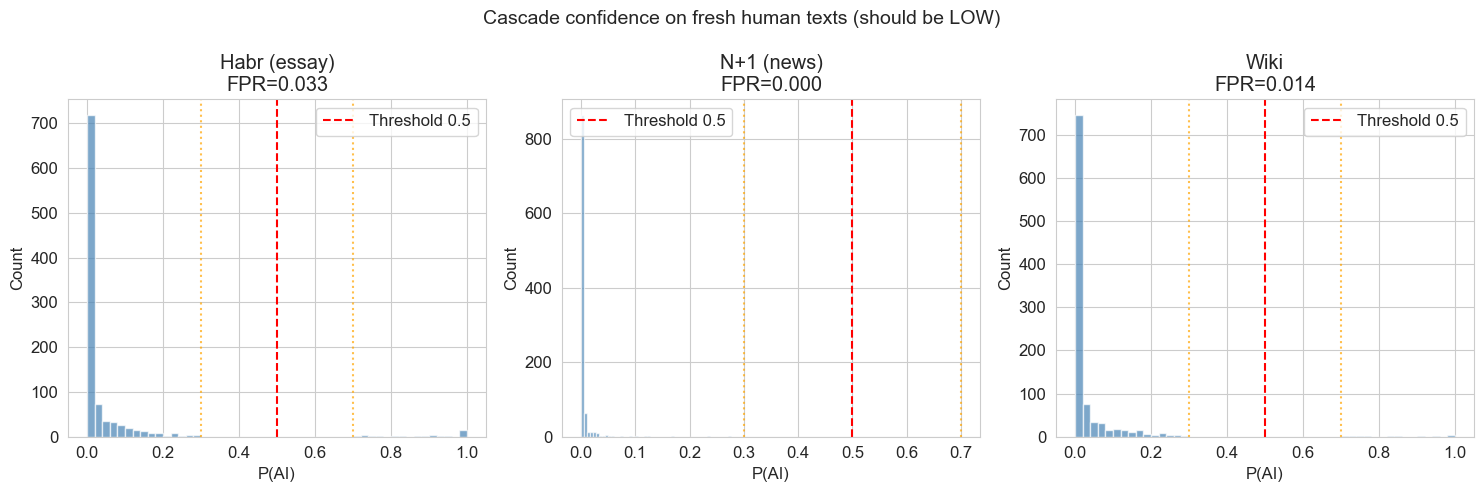

In [11]:
# Визуализация: распределение confidence по источникам
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, key, data) in zip(axes, [("Habr (essay)", "habr", habr_fresh), ("N+1 (news)", "nplus1", nplus1_fresh), ("Wiki", "wiki", wiki_fresh)]):
    texts = [r["text"] for r in data]
    probs = cascade_predict(texts)[0]
    
    ax.hist(probs, bins=50, alpha=0.7, color="steelblue", edgecolor="white")
    ax.axvline(0.5, color="red", linestyle="--", label="Threshold 0.5")
    ax.axvline(0.3, color="orange", linestyle=":", alpha=0.7)
    ax.axvline(0.7, color="orange", linestyle=":", alpha=0.7)
    ax.set_title(f"{name}\nFPR={results_fresh[key]['fpr']:.3f}")
    ax.set_xlabel("P(AI)")
    ax.set_ylabel("Count")
    ax.legend()

plt.suptitle("Cascade confidence on fresh human texts (should be LOW)", fontsize=14)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "artifacts/temporal_robustness_hist.png"), dpi=150, bbox_inches="tight")
plt.show()

## 6. Degradation Curve — Edited AI

In [12]:
from difflib import SequenceMatcher

# Загрузим оригиналы для расчёта edit_ratio (для старых файлов без ratio в meta)
test_tm = load_jsonl(PROJECT_ROOT / "data/splits/test_tm.jsonl")
orig_map = {r["doc_id"]: r["text"] for r in test_tm if r.get("label") == 1 or r.get("label") == "ai"}

# Прогоняем cascade на каждом уровне
results_edited = []

for level, rows in sorted(edited_data.items()):
    texts = [r["text"] for r in rows]
    print(f"\n=== {level} ({len(texts)} texts) ===")
    
    probs, methods = cascade_predict(texts)
    
    for i, r in enumerate(rows):
        # Edit ratio
        if "edit_ratio" in r.get("meta", {}):
            ratio = r["meta"]["edit_ratio"]
        else:
            orig_id = r["meta"]["original_doc_id"]
            orig_text = orig_map.get(orig_id, "")
            ratio = SequenceMatcher(None, orig_text, r["text"]).ratio() if orig_text else None
        
        results_edited.append({
            "level": level,
            "edit_ratio": ratio,
            "prob_ai": probs[i],
            "method": methods[i],
            "pred": int(probs[i] >= 0.5),
            "domain": r.get("domain", ""),
        })

df_edited = pd.DataFrame(results_edited)
print(f"\nTotal: {len(df_edited)} records")
print(df_edited.groupby("level").agg({"edit_ratio": "median", "prob_ai": ["mean", "median"], "pred": "mean"}).round(3))


=== heavy_edit (150 texts) ===
  Cascade: 150 texts, 99.3% fast path (TF-IDF), 1 uncertain → Transformer

=== light_edit (150 texts) ===
  Cascade: 150 texts, 94.7% fast path (TF-IDF), 8 uncertain → Transformer

=== mixed (150 texts) ===
  Cascade: 150 texts, 77.3% fast path (TF-IDF), 34 uncertain → Transformer

=== replace_10 (100 texts) ===
  Cascade: 100 texts, 96.0% fast path (TF-IDF), 4 uncertain → Transformer

=== replace_30 (100 texts) ===
  Cascade: 100 texts, 95.0% fast path (TF-IDF), 5 uncertain → Transformer

=== replace_50 (100 texts) ===
  Cascade: 100 texts, 93.0% fast path (TF-IDF), 7 uncertain → Transformer

Total: 750 records
           edit_ratio prob_ai          pred
               median    mean median   mean
level                                      
heavy_edit      0.199   0.989  1.000  1.000
light_edit      0.982   0.913  0.999  0.913
mixed           0.363   0.449  0.191  0.447
replace_10      0.927   0.927  0.998  0.930
replace_30      0.729   0.942  0.998  0.

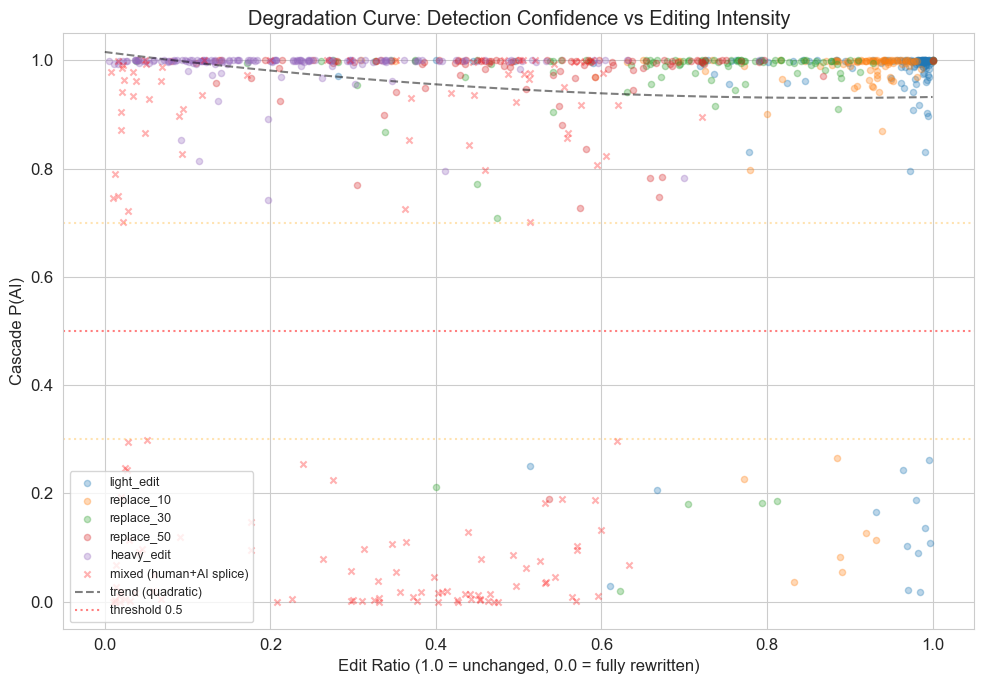

In [13]:
# Degradation curve: edit_ratio vs cascade confidence
fig, ax = plt.subplots(figsize=(10, 7))

# Отдельные маркеры для replace_N (на кривой) и mixed (отдельно)
for level in ["light_edit", "replace_10", "replace_30", "replace_50", "heavy_edit"]:
    sub = df_edited[df_edited["level"] == level]
    if len(sub) == 0:
        continue
    ax.scatter(sub["edit_ratio"], sub["prob_ai"], alpha=0.3, s=20, label=level)

# Mixed — отдельный маркер
sub_mixed = df_edited[df_edited["level"] == "mixed"]
if len(sub_mixed) > 0:
    ax.scatter(sub_mixed["edit_ratio"], sub_mixed["prob_ai"], alpha=0.3, s=20,
              marker="x", color="red", label="mixed (human+AI splice)")

# Линия тренда (без mixed)
df_trend = df_edited[df_edited["level"] != "mixed"].dropna(subset=["edit_ratio"])
if len(df_trend) > 10:
    z = np.polyfit(df_trend["edit_ratio"], df_trend["prob_ai"], 2)
    x_line = np.linspace(0, 1, 100)
    ax.plot(x_line, np.polyval(z, x_line), "k--", alpha=0.5, label="trend (quadratic)")

ax.axhline(0.5, color="red", linestyle=":", alpha=0.5, label="threshold 0.5")
ax.axhline(0.3, color="orange", linestyle=":", alpha=0.3)
ax.axhline(0.7, color="orange", linestyle=":", alpha=0.3)
ax.set_xlabel("Edit Ratio (1.0 = unchanged, 0.0 = fully rewritten)")
ax.set_ylabel("Cascade P(AI)")
ax.set_title("Degradation Curve: Detection Confidence vs Editing Intensity")
ax.legend(loc="lower left", fontsize=9)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "artifacts/degradation_curve.png"), dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# Сводная таблица по уровням
summary = df_edited.groupby("level").agg(
    n=("prob_ai", "count"),
    median_ratio=("edit_ratio", "median"),
    median_prob=("prob_ai", "median"),
    mean_prob=("prob_ai", "mean"),
    recall=("pred", "mean"),  # доля AI-текстов, корректно обнаруженных
    n_high=("prob_ai", lambda x: (x >= 0.70).sum()),
    n_medium=("prob_ai", lambda x: ((x >= 0.30) & (x < 0.70)).sum()),
    n_low=("prob_ai", lambda x: (x < 0.30).sum()),
).round(3)

# Сортировка по edit_ratio (от raw к full_rewrite)
summary = summary.sort_values("median_ratio", ascending=False)

print("\n=== Degradation Summary ===")
print(summary.to_string())


=== Degradation Summary ===
              n  median_ratio  median_prob  mean_prob  recall  n_high  n_medium  n_low
level                                                                                 
light_edit  150         0.982        0.999      0.913   0.913     137         0     13
replace_10  100         0.927        0.998      0.927   0.930      93         0      7
replace_30  100         0.729        0.998      0.942   0.950      95         0      5
replace_50  100         0.536        0.998      0.968   0.990      99         0      1
mixed       150         0.363        0.191      0.449   0.447      67         0     83
heavy_edit  150         0.199        1.000      0.989   1.000     150         0      0


## 7. Сохранение результатов

In [ ]:
# Сохраняем таблицы для ВКР
df_fpr.to_csv(PROJECT_ROOT / "artifacts/temporal_fpr.csv")
summary.to_csv(PROJECT_ROOT / "artifacts/degradation_summary.csv")
df_edited.to_csv(PROJECT_ROOT / "artifacts/degradation_raw.csv", index=False)

print("Saved:")
print("  artifacts/temporal_fpr.csv")
print("  artifacts/degradation_summary.csv")
print("  artifacts/degradation_raw.csv")
print("  artifacts/temporal_robustness_hist.png")
print("  artifacts/degradation_curve.png")

Saved:
  artifacts/temporal_fpr.csv
  artifacts/degradation_summary.csv
  artifacts/degradation_raw.csv
  artifacts/temporal_robustness_hist.png
  artifacts/degradation_curve.png


: 